## Análisis exploratorio - 3.2 Análisis bivariable

### By:
Maria Camila Aristizábal Aguirre

### Date:
2026-08-17

### Description:
Relación de cada variable numérica con la variable objetivo (Outcome), y correlaciones entre variables numéricas entre sí.

## 📚 Import  libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.float_format", "{:.2f}".format)

DATA_DIR = Path("../../data")

## 💾 Load data

In [2]:
df = pd.read_parquet(DATA_DIR / "02_intermediate" / "diabetes_type_fixed.parquet")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               986 non-null    Int8   
 1   Glucose                   982 non-null    float64
 2   BloodPressure             942 non-null    float64
 3   SkinThickness             689 non-null    float64
 4   Insulin                   501 non-null    float64
 5   BMI                       978 non-null    float64
 6   DiabetesPedigreeFunction  989 non-null    float64
 7   Age                       991 non-null    Int8   
 8   Outcome                   975 non-null    boolean
dtypes: Int8(2), boolean(1), float64(6)
memory usage: 52.5 KB


## Alcance de este análisis

El dataset no tiene variables categóricas nominales — todas las predictoras son numéricas y la variable objetivo
(`Outcome`) es booleana. Por lo tanto, aquí solo se cubre:

- **Outcome vs cada variable numérica** (boxplot + densidad)
- **Variable numérica vs variable numérica** (matriz de correlación)

No aplican las secciones de "categórica vs categórica" ni "categórica vs numérica"

Para comparar contra `Outcome` se excluyen las 19 filas sin etiqueta. El `df` completo no se modifica, solo se usa una
vista filtrada para estos gráficos.

In [3]:
df_con_outcome = df[df["Outcome"].notna()].copy()
df_con_outcome["Outcome"] = df_con_outcome["Outcome"].astype(bool)

len(df_con_outcome)

975

## Outcome vs variables numéricas: boxplots

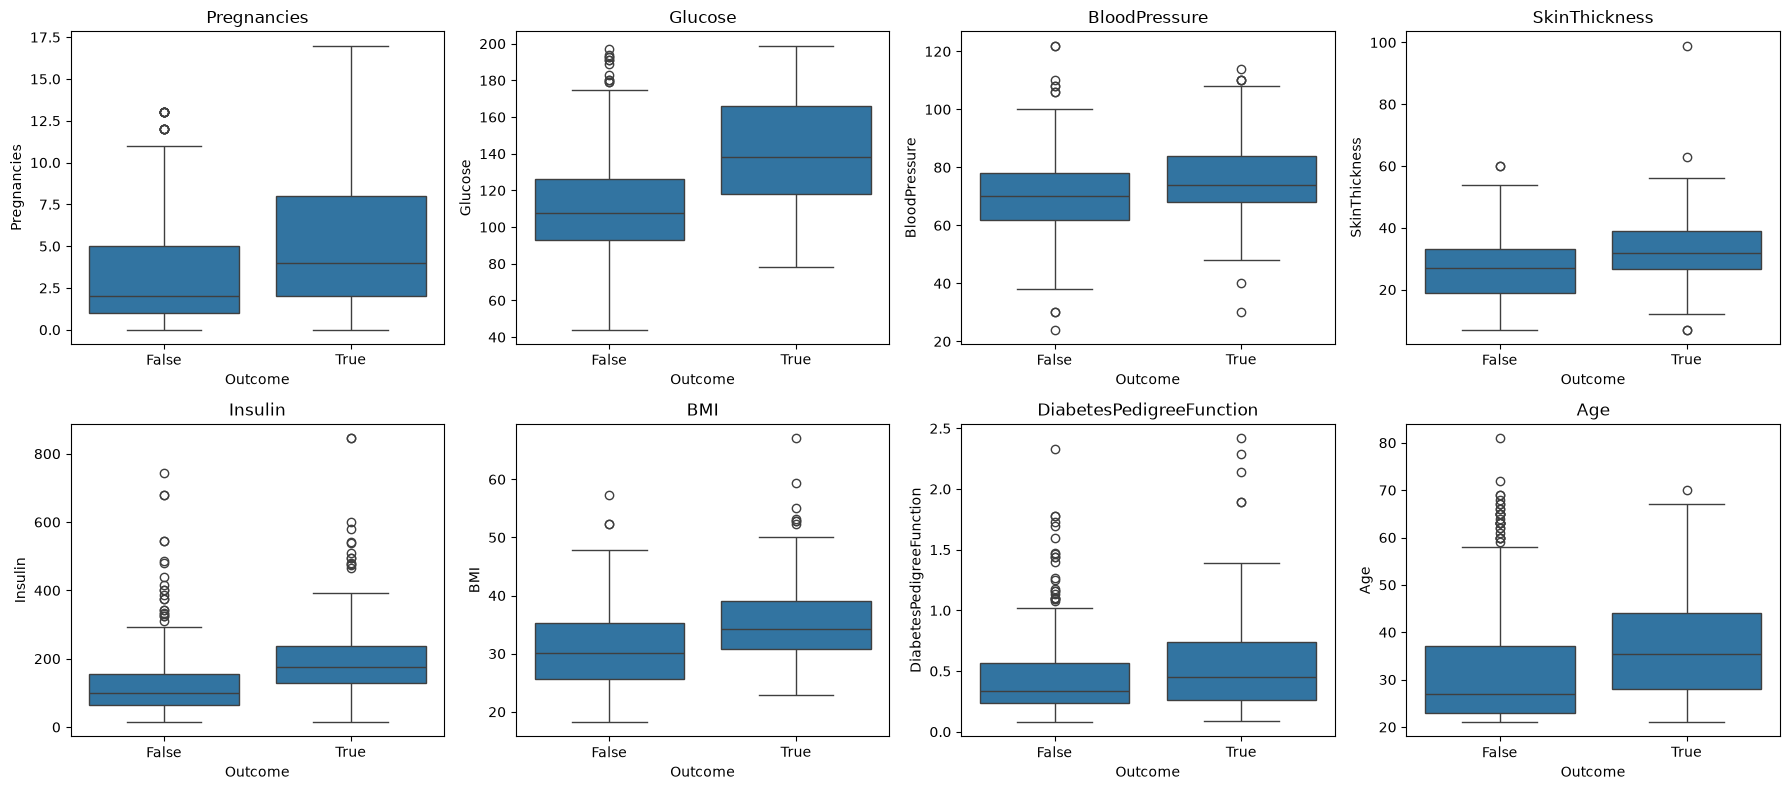

In [4]:
COLUMNAS_NUMERICAS = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, ax in zip(COLUMNAS_NUMERICAS, axes.flatten(), strict=True):
    sns.boxplot(data=df_con_outcome, x="Outcome", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Outcome vs variables numéricas: densidad


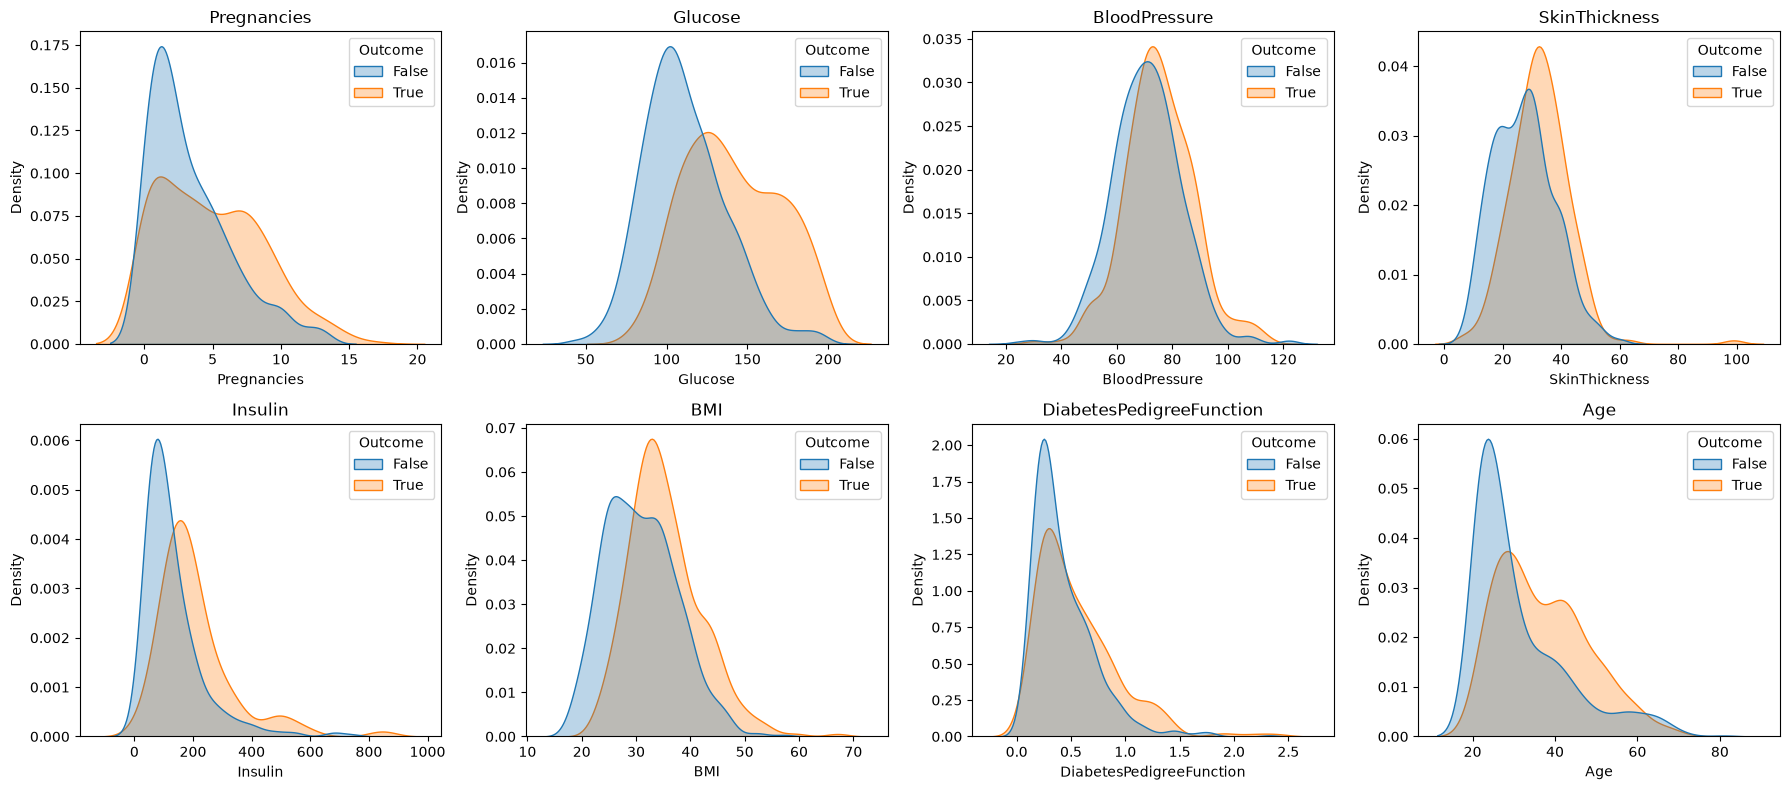

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, ax in zip(COLUMNAS_NUMERICAS, axes.flatten(), strict=True):
    sns.kdeplot(
        data=df_con_outcome,
        x=col,
        hue="Outcome",
        ax=ax,
        common_norm=False,
        fill=True,
        alpha=0.3,
    )
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Variables numéricas entre sí: matriz de correlación

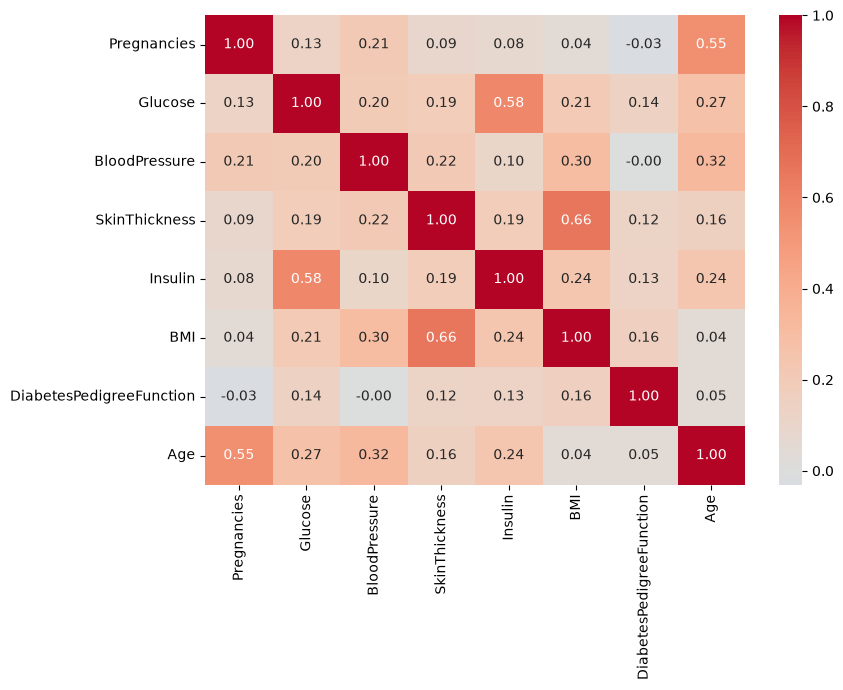

In [6]:
matriz_corr = df[COLUMNAS_NUMERICAS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.tight_layout()
plt.show()

## Hallazgos - Análisis bivariable

### Outcome vs. variables numéricas (boxplots)

Se observa separación clara entre las medianas de `Outcome=False` y `Outcome=True` en:

- **Glucose**: la variable con mayor separación visual. Mediana ~107 en False vs. ~140 en True, con las cajas casi sin solaparse. Es el candidato más fuerte como predictor individual.
- **Insulin**: mediana ~95 (False) vs. ~169 (True), con desplazamiento marcado hacia arriba en el grupo True, aunque ambos grupos mantienen outliers altos (hasta ~740-846).
- **Pregnancies**: mediana 2 (False) vs. 4 (True), caja más ancha y desplazada en True.
- **Age**: mediana ~27 (False) vs. ~35 (True), separación moderada-clara.

Separación moderada:
- **BMI**: mediana ~30 (False) vs. ~34 (True).
- **DiabetesPedigreeFunction**: mediana ~0.32 (False) vs. ~0.44 (True), con outliers altos en ambos grupos (hasta ~2.3).

Separación débil (cajas muy solapadas):
- **BloodPressure**: mediana ~69 vs. ~74.
- **SkinThickness**: mediana ~27 vs. ~31.

### Outcome vs. variables numéricas (KDE)

Las curvas de densidad confirman el mismo patrón que los boxplots:

- **Glucose** muestra el corrimiento más nítido hacia la derecha en el grupo True (pico ~130-150) respecto a False (pico ~100-110).
- **Pregnancies** y **Age** muestran curvas True más planas/dispersas hacia valores altos, mientras que False se concentra en valores bajos (picos agudos cerca de 0-2 en Pregnancies y ~22-25 años en Age).
- **Insulin** conserva el pico bajo en ambos grupos, pero True presenta más densidad en la cola derecha (valores altos).
- **BMI** presenta picos distinguibles pero cercanos (~29 vs. ~35).
- **BloodPressure**, **SkinThickness** y **DiabetesPedigreeFunction** muestran curvas casi superpuestas entre ambos grupos, consistente con la débil separación vista en los boxplots.

En conjunto, Glucose, Insulin, Pregnancies y Age son las variables que más diferencian a los dos grupos de Outcome; BloodPressure y SkinThickness son las que menos aportan por sí solas para distinguir la clase.

### Correlación entre variables numéricas (heatmap)

Las tres correlaciones más fuertes entre predictores son:

- **SkinThickness–BMI: 0.66** (la más alta del dataset), esperable clínicamente: ambas variables reflejan composición corporal/adiposidad.
- **Glucose–Insulin: 0.58**, coherente con la fisiología de la regulación de glucosa (la insulina responde a los niveles de glucosa).
- **Pregnancies–Age: 0.55**, relación demográfica esperada (a mayor edad, más embarazos acumulados posibles).

El resto de correlaciones entre predictores es débil a moderada (rango ~0.03 a 0.32), sin señales de multicolinealidad severa (El resto de correlaciones entre predictores es débil a moderada (rango ~0.03 a 0.32), sin señales de multicolinealidad severa — el valor más alto (0.66) está lejos de los umbrales típicos de preocupación (>0.8-0.9)). Las correlaciones más cercanas a cero son BloodPressure–DiabetesPedigreeFunction (-0.00), Pregnancies–DiabetesPedigreeFunction (-0.03) y BMI–Age (0.04).

**Nota metodológica**: estas son correlaciones lineales (Pearson) sobre variables con outliers y datos faltantes (NaN) aún sin imputar; los pares con imputación pendiente (Insulin 49.6% NA, SkinThickness 30.7% NA) deben revisarse tras el tratamiento de faltantes en la fase de Feature Engineering, ya que el patrón de missingness podría afectar estas estimaciones.